# 06 — Sentiment Analysis: Analysis & Visualisation

Visualises sentiment toward China and the US in local press across Jordan, Mozambique, and Zambia.
Loads the scored datasets saved by `05_sentiment_load_clean.ipynb`.

## Helper Functions

| Function | Signature | What it does |
|---|---|---|
| `contains_any` | `contains_any(text, keywords)` | Returns `True` if any keyword appears (case-insensitive) in `text`. Used in section 4 to filter headlines to development-related coverage. |
| `sentiment_pct` | `sentiment_pct(df, countries, sentiment_order)` | Computes the % of headlines in each sentiment category for every country × period combination. Returns a long-format DataFrame with columns `country`, `period`, `sentiment`, `pct`, `n`. |
| `plot_sentiment` | `plot_sentiment(pct_df, title, output_path, sentiment_order, sent_colors, countries)` | Draws a grouped bar chart with one panel per country showing Pre vs Post-inauguration sentiment share. Saves to `output_path`. |
| `net_sentiment_shift` | `net_sentiment_shift(df, countries)` | Computes net positive sentiment (% Positive − % Negative) by country × period. Returns a long-format DataFrame used in the combined overview charts. |

In [2]:
import os, warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import requests
import gdown
from tqdm.auto import tqdm

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'

os.makedirs('../output', exist_ok=True)

# Ollama config — needed for framing analysis (section 10)
OLLAMA_URL   = 'http://localhost:11434/api/generate'
OLLAMA_MODEL = 'llama3'

def contains_any(text, keywords):
    t = str(text).lower()
    return any(kw in t for kw in keywords)

In [3]:
# Load scored headlines from Google Drive


gdown.download(id='1KsdVEsUrQeKl9uRWDPcCD5mf6c2YpjYA', output='df_china_scored.csv', quiet=False)
gdown.download(id='1PI7aaVL2YL0M5zxwOpXRaVyziMsq03ie',    output='df_us_scored.csv',    quiet=False)

df_china = pd.read_csv('df_china_scored.csv')
df_us    = pd.read_csv('df_us_scored.csv')

print(f'df_china: {len(df_china):,} rows')
print(f'df_us:    {len(df_us):,} rows')
print(f'Columns: {df_china.columns.tolist()}')

Downloading...
From: https://drive.google.com/uc?id=1KsdVEsUrQeKl9uRWDPcCD5mf6c2YpjYA
To: /Users/charlesphillips/Documents/GitHub/qss20-final-project/code/df_china_scored.csv
100%|████████████████████████████████████████| 913k/913k [00:00<00:00, 6.64MB/s]


'df_china_scored.csv'

Downloading...
From: https://drive.google.com/uc?id=1PI7aaVL2YL0M5zxwOpXRaVyziMsq03ie
To: /Users/charlesphillips/Documents/GitHub/qss20-final-project/code/df_us_scored.csv
100%|████████████████████████████████████████| 907k/907k [00:00<00:00, 9.95MB/s]


'df_us_scored.csv'

df_china: 3,000 rows
df_us:    2,998 rows
Columns: ['country', 'topic', 'period', 'publish_date', 'title', 'language', 'media_name', 'url', 'mentions_china', 'mentions_us', 'sentiment', 'score']


---
## 1. China Sentiment — Before vs After Inauguration

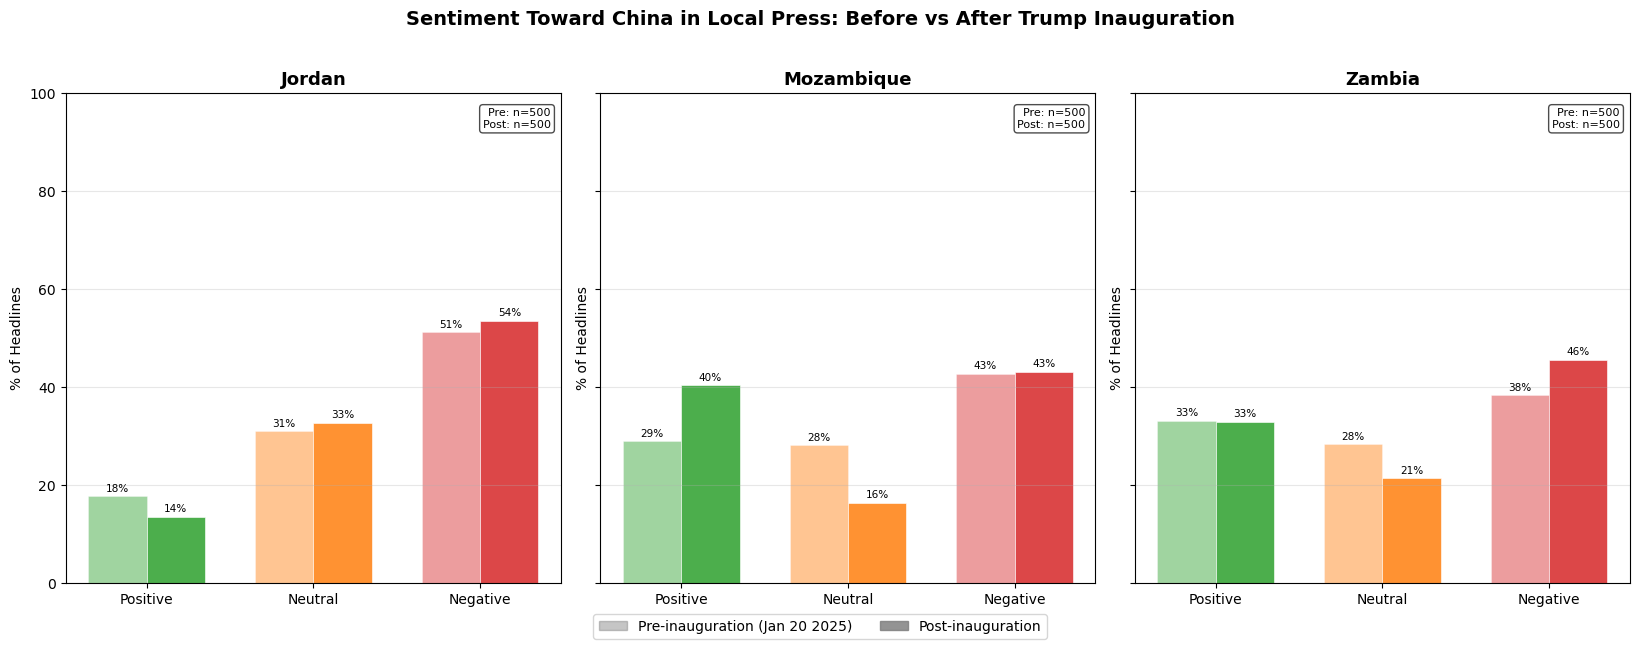

Saved -> ../output/sentiment_china.png


In [4]:
# ── Customisable ──────────────────────────────────────────────────────────
COUNTRIES       = ['Jordan', 'Mozambique', 'Zambia']
SENTIMENT_ORDER = ['Positive', 'Neutral', 'Negative']
SENT_COLORS     = {'Positive': '#2ca02c', 'Neutral': '#ff7f0e', 'Negative': '#d62728'}
OUTPUT_CHINA    = '../output/sentiment_china.png'
OUTPUT_US       = '../output/sentiment_us.png'
OUTPUT_COMBINED = '../output/sentiment_combined.png'
# ─────────────────────────────────────────────────────────────────────────

def sentiment_pct(df, countries, sentiment_order):
    """Return a DataFrame of sentiment % by country x period."""
    rows = []
    for country in countries:
        for period in ['Pre-inauguration', 'Post-inauguration']:
            sub = df[(df['country'] == country) & (df['period'] == period)]
            if len(sub) == 0:
                continue
            counts = sub['sentiment'].value_counts(normalize=True) * 100
            for sent in sentiment_order:
                rows.append({
                    'country': country, 'period': period,
                    'sentiment': sent, 'pct': counts.get(sent, 0.0),
                    'n': len(sub)
                })
    return __import__('pandas').DataFrame(rows)


def plot_sentiment(pct_df, title, output_path, sentiment_order, sent_colors, countries):
    """Grouped bar chart: one panel per country, bars = sentiment x period."""
    import numpy as np, matplotlib.patches as mpatches
    n_countries = len(countries)
    fig, axes = plt.subplots(1, n_countries, figsize=(5.5 * n_countries, 6), sharey=True)
    if n_countries == 1:
        axes = [axes]

    periods = ['Pre-inauguration', 'Post-inauguration']
    x       = np.arange(len(sentiment_order))
    width   = 0.35

    for ax, country in zip(axes, countries):
        sub = pct_df[pct_df['country'] == country]
        for j, period in enumerate(periods):
            pdata = sub[sub['period'] == period].set_index('sentiment')
            if pdata.empty:
                continue
            values = [pdata['pct'].get(s, 0) for s in sentiment_order]
            offset = (j - 0.5) * width
            bars   = ax.bar(
                x + offset, values, width,
                color=[sent_colors[s] for s in sentiment_order],
                alpha=0.85 if period == 'Post-inauguration' else 0.45,
                edgecolor='white', linewidth=0.5
            )
            for bar, val in zip(bars, values):
                if val > 2:
                    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                            f'{val:.0f}%', ha='center', va='bottom', fontsize=7.5)

        pre_n  = sub[sub['period'] == 'Pre-inauguration']['n'].max() if not sub.empty else 0
        post_n = sub[sub['period'] == 'Post-inauguration']['n'].max() if not sub.empty else 0
        ax.set_title(country, fontsize=13, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(sentiment_order, fontsize=10)
        ax.set_ylabel('% of Headlines', fontsize=10)
        ax.set_ylim(0, 100)
        ax.grid(axis='y', alpha=0.3)
        ax.text(0.98, 0.97, f'Pre: n={int(pre_n)}\nPost: n={int(post_n)}',
                transform=ax.transAxes, fontsize=8, va='top', ha='right',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

    legend_patches = [
        mpatches.Patch(color='gray', alpha=0.45, label='Pre-inauguration (Jan 20 2025)'),
        mpatches.Patch(color='gray', alpha=0.85, label='Post-inauguration'),
    ]
    fig.legend(handles=legend_patches, loc='lower center', ncol=2,
               fontsize=10, bbox_to_anchor=(0.5, -0.04))
    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved -> {output_path}')


china_pct = sentiment_pct(df_china, COUNTRIES, SENTIMENT_ORDER)
plot_sentiment(
    china_pct,
    title='Sentiment Toward China in Local Press: Before vs After Trump Inauguration',
    output_path=OUTPUT_CHINA,
    sentiment_order=SENTIMENT_ORDER,
    sent_colors=SENT_COLORS,
    countries=COUNTRIES
)

## 2. US Sentiment — Before vs After Inauguration

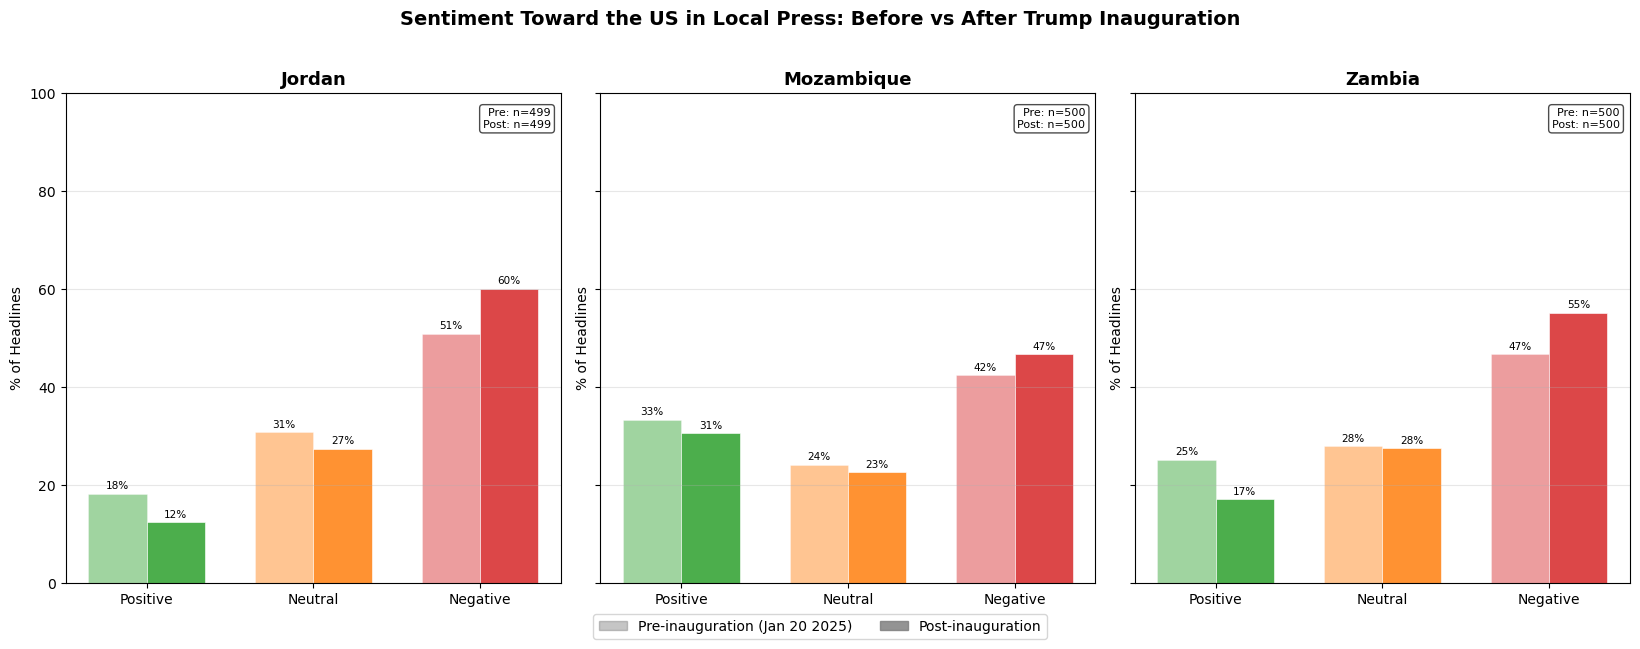

Saved -> ../output/sentiment_us.png


In [19]:
us_pct = sentiment_pct(df_us, COUNTRIES, SENTIMENT_ORDER)
plot_sentiment(
    us_pct,
    title='Sentiment Toward the US in Local Press: Before vs After Trump Inauguration',
    output_path=OUTPUT_US,
    sentiment_order=SENTIMENT_ORDER,
    sent_colors=SENT_COLORS,
    countries=COUNTRIES
)

## 3. Combined Overview: China vs US Sentiment Shift by Country

In [5]:
def net_sentiment_shift(df, countries):
    """
    Net positive sentiment = %Positive - %Negative.
    Returns a table showing the shift from pre to post per country.
    """
    rows = []
    for country in countries:
        for period in ['Pre-inauguration', 'Post-inauguration']:
            sub = df[(df['country'] == country) & (df['period'] == period)]
            if len(sub) == 0:
                continue
            counts = sub['sentiment'].value_counts(normalize=True) * 100
            net    = counts.get('Positive', 0) - counts.get('Negative', 0)
            rows.append({'country': country, 'period': period, 'net_positive': net, 'n': len(sub)})
    return pd.DataFrame(rows)

china_net = net_sentiment_shift(df_china, COUNTRIES).assign(topic='China')
us_net    = net_sentiment_shift(df_us,    COUNTRIES).assign(topic='US')
net_df    = pd.concat([china_net, us_net])

# Pivot to show pre vs post side by side
pivot = (
    net_df
    .pivot_table(index=['topic', 'country'], columns='period', values='net_positive')
    .reset_index()
)
pivot['shift'] = pivot.get('Post-inauguration', 0) - pivot.get('Pre-inauguration', 0)
pivot.columns.name = None
print("Net positive sentiment (% Positive − % Negative):")
pivot.round(1)

Net positive sentiment (% Positive − % Negative):


,topic,country,Post-inauguration,Pre-inauguration,shift
0,China,Jordan,-40.0,-33.4,-6.6
1,China,Mozambique,-2.8,-13.8,11.0
2,China,Zambia,-12.6,-5.2,-7.4
3,US,Jordan,-46.5,-31.5,-15.0
4,US,Mozambique,-16.6,-7.2,-9.4
5,US,Zambia,-36.2,-19.6,-16.6


Text(-0.175, -34.900000000000006, '-33')

Text(0.825, -32.9629258517034, '-31')

Text(0.175, -41.5, '-40')

Text(1.175, -47.992985971943895, '-46')

Text(0.5, 1.0, 'Jordan')

...

Text(1.175, -37.7, '-36')

Text(0.5, 1.0, 'Zambia')

[Text(0, 0, 'China'), Text(1, 0, 'US')]

Text(0, 0.5, 'Net Positive Sentiment\n(% Positive − % Negative)')

Text(0.5, 1.02, 'Net Positive Sentiment in China vs US Coverage\nBefore and After Trump Inauguration')

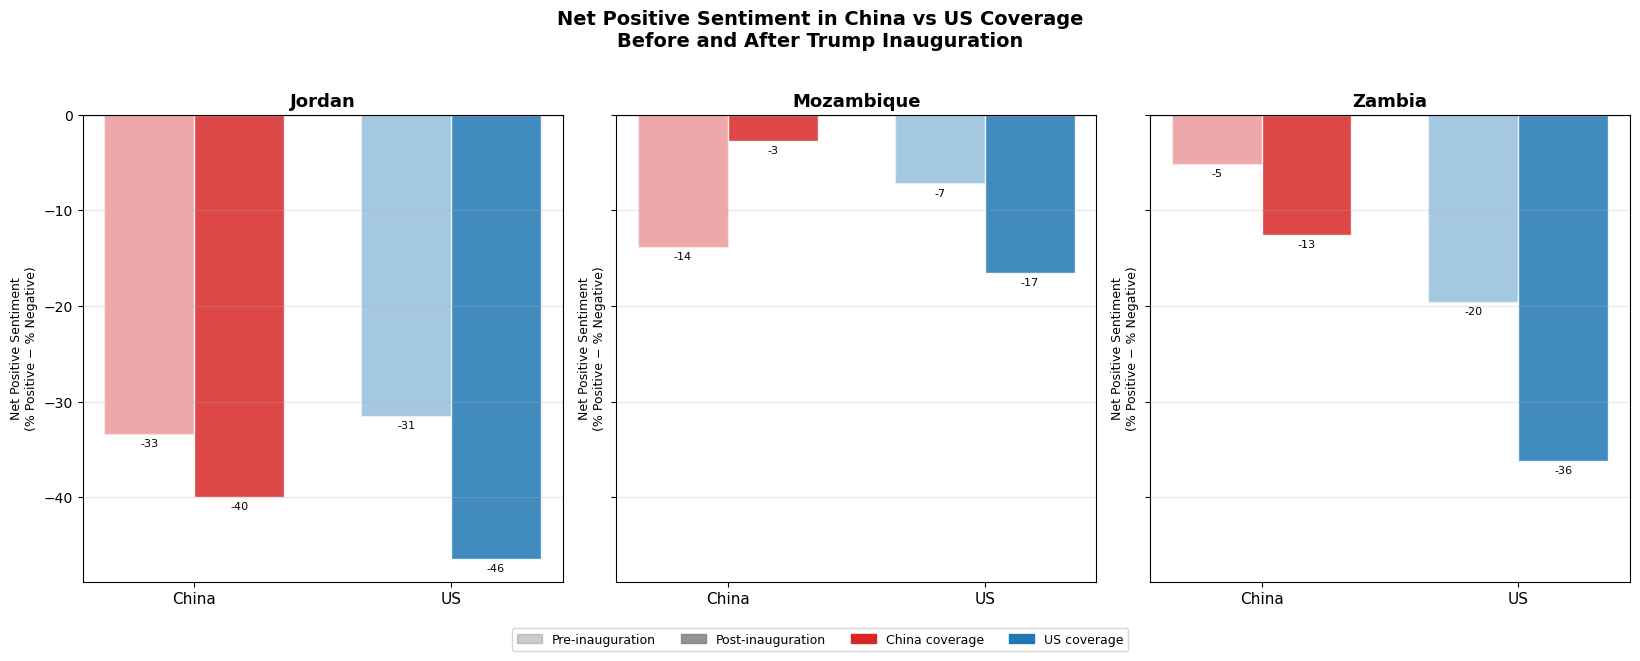

Saved → ../output/sentiment_combined.png


In [6]:
# Combined grouped bar chart: China vs US net sentiment, pre vs post, by country
fig, axes = plt.subplots(1, len(COUNTRIES), figsize=(5.5 * len(COUNTRIES), 6), sharey=True)
if len(COUNTRIES) == 1:
    axes = [axes]

topics  = ['China', 'US']
t_colors = {'China': '#d62728', 'US': '#1f77b4'}
periods  = ['Pre-inauguration', 'Post-inauguration']
x        = np.arange(len(topics))
width    = 0.35

for ax, country in zip(axes, COUNTRIES):
    for j, period in enumerate(periods):
        vals   = []
        for topic in topics:
            sub = net_df[(net_df['country'] == country) &
                         (net_df['period']  == period)  &
                         (net_df['topic']   == topic)]
            vals.append(sub['net_positive'].values[0] if len(sub) > 0 else 0)

        offset = (j - 0.5) * width
        bars   = ax.bar(
            x + offset, vals, width,
            color=[t_colors[t] for t in topics],
            alpha=0.85 if period == 'Post-inauguration' else 0.40,
            edgecolor='white'
        )
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + (0.3 if val >= 0 else -1.5),
                    f'{val:+.0f}', ha='center', va='bottom', fontsize=8)

    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(country, fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(topics, fontsize=11)
    ax.set_ylabel('Net Positive Sentiment\n(% Positive − % Negative)', fontsize=9)
    ax.grid(axis='y', alpha=0.3)

legend_patches = [
    mpatches.Patch(color='gray', alpha=0.40, label='Pre-inauguration'),
    mpatches.Patch(color='gray', alpha=0.85, label='Post-inauguration'),
    mpatches.Patch(color=t_colors['China'],  label='China coverage'),
    mpatches.Patch(color=t_colors['US'],     label='US coverage'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=4,
           fontsize=9, bbox_to_anchor=(0.5, -0.06))
fig.suptitle(
    'Net Positive Sentiment in China vs US Coverage\nBefore and After Trump Inauguration',
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(OUTPUT_COMBINED, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {OUTPUT_COMBINED}")

---
## 4. Development-Specific Sentiment Analysis

Restricts the analysis to headlines about aid, development programs, and foreign assistance — filtering out general political and trade coverage — then compares sentiment before and after Trump's inauguration.

In [7]:
# ── Customisable: development keyword filter ──────────────────────────
DEV_KEYWORDS = [
    # English — core foreign aid / development program terms
    'aid', 'assistance', 'development', 'infrastructure', 'investment',
    'loan', 'grant', 'fund', 'poverty', 'humanitarian', 'health', 'education',
    'usaid', 'project', 'programme', 'program', 'water', 'sanitation',
    'food security', 'finance', 'bank', 'debt', 'budget', 'cooperation',
    'capacity', 'technical', 'training', 'scholarship', 'vocational',
    'nutrition', 'vaccine', 'clinic', 'hospital', 'school', 'teacher',
    # Arabic
    'معونة', 'مساعدة', 'تنمية', 'بنية تحتية'
    , 'استثمار', 'قرض', 'منحة', 'صندوق', 'فقر', 'إنساني', 'صحة', 'تعليم',
    'USAID', 'مشروع', 'برنامج', 'برنامج', 'مياه', 'صرف صحي',
'أمن غذائي', 'تمويل', 'بنك', 'دين', 'ميزانية', 'تعاون',
'قدرات', 'تقني', 'تدريب', 'منحة دراسية', 'مهني',
'تغذية', 'لقاح', 'عيادة', 'مستشفى', 'مدرسة', 'معلم',
    # Portuguese
    'ajuda', 'assistência', 'desenvolvimento', 'infra-estruturas', 'investimento',
'empréstimo', 'subvenção', 'fundo', 'pobreza', 'humanitário', 'saúde', 'educação', 'USAID', 'projecto', 'programa', 'água', 'saneamento',
'segurança alimentar', 'finanças', 'banco', 'dívida', 'orçamento', 'cooperação',

'capacidade', 'técnico', 'formação', 'bolsa de estudo', 'profissionalizante',

'nutrição', 'vacina', 'clínica', 'hospital', 'escola', 'professor']
# ─────────────────────────────────────────────────────────────────────

df_china_dev = df_china[df_china['title'].apply(lambda t: contains_any(t, DEV_KEYWORDS))].copy()
df_us_dev    = df_us[df_us['title'].apply(lambda t: contains_any(t, DEV_KEYWORDS))].copy()

print(f'Development headlines — China: {len(df_china_dev)}  |  US: {len(df_us_dev)}')
print('\nChina dev headlines by country/period:')
print(df_china_dev.groupby(['country', 'period']).size().unstack(fill_value=0))
print('\nUS dev headlines by country/period:')
print(df_us_dev.groupby(['country', 'period']).size().unstack(fill_value=0))


Development headlines — China: 254  |  US: 229

China dev headlines by country/period:
period      Post-inauguration  Pre-inauguration
country                                        
Jordan                     38                46
Mozambique                 22                33
Zambia                     36                79

US dev headlines by country/period:
period      Post-inauguration  Pre-inauguration
country                                        
Jordan                     33                40
Mozambique                 28                28
Zambia                     40                60


### 4a. China — Development Headline Sentiment

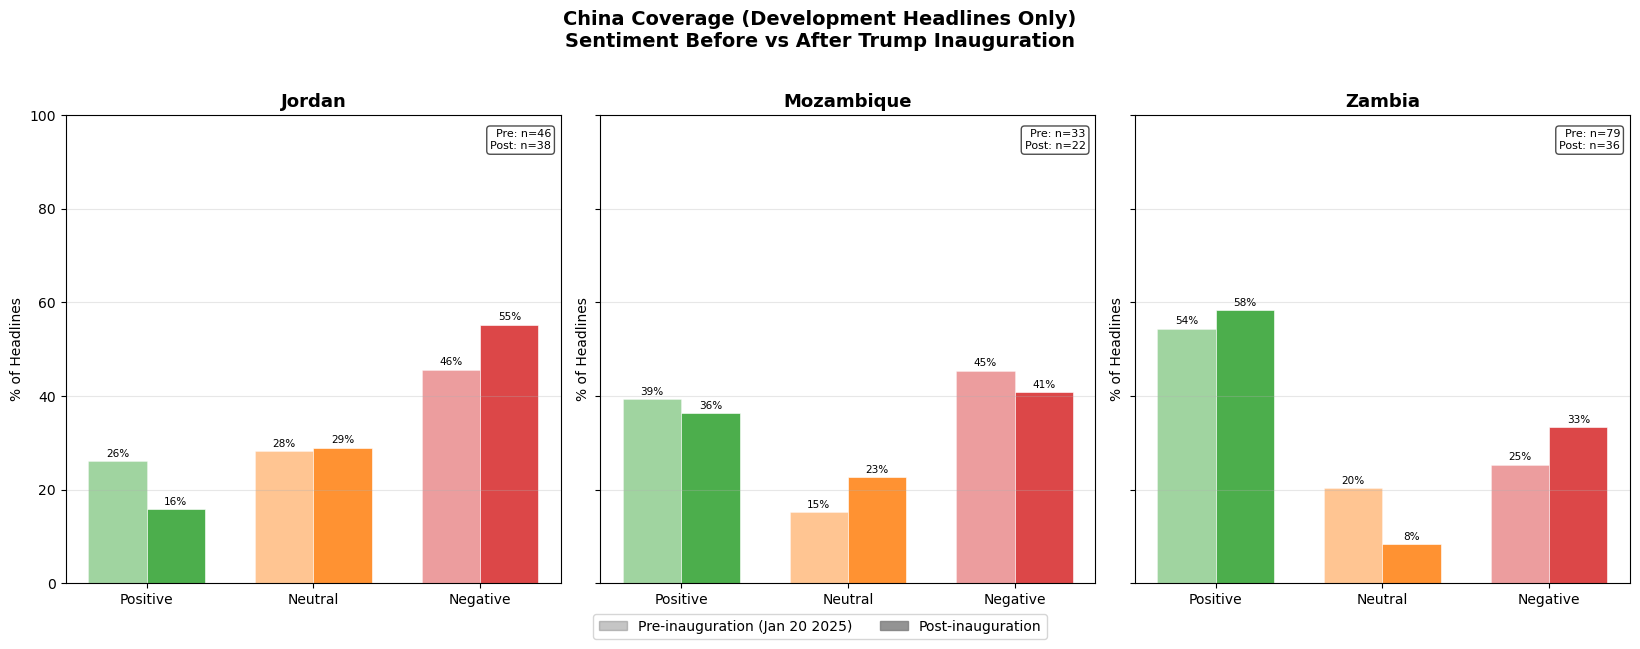

Saved -> ../output/sentiment_china_dev.png


In [8]:
OUTPUT_CHINA_DEV = '../output/sentiment_china_dev.png'

china_dev_pct = sentiment_pct(df_china_dev, COUNTRIES, SENTIMENT_ORDER)
plot_sentiment(
    china_dev_pct,
    title='China Coverage (Development Headlines Only)\nSentiment Before vs After Trump Inauguration',
    output_path=OUTPUT_CHINA_DEV,
    sentiment_order=SENTIMENT_ORDER,
    sent_colors=SENT_COLORS,
    countries=COUNTRIES,
)


### 4b. US — Development Headline Sentiment

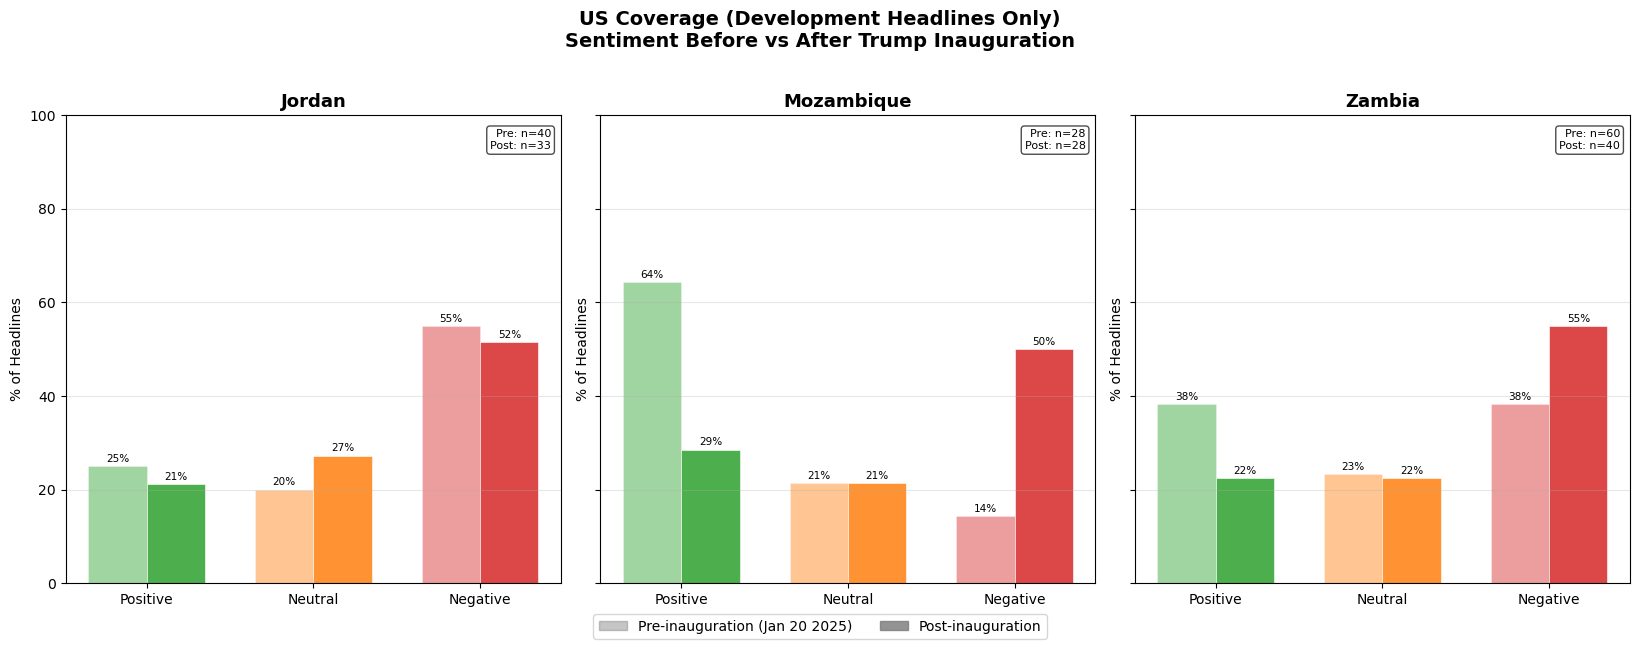

Saved -> ../output/sentiment_us_dev.png


In [10]:
OUTPUT_US_DEV = '../output/sentiment_us_dev.png'

us_dev_pct = sentiment_pct(df_us_dev, COUNTRIES, SENTIMENT_ORDER)
plot_sentiment(
    us_dev_pct,
    title='US Coverage (Development Headlines Only)\nSentiment Before vs After Trump Inauguration',
    output_path=OUTPUT_US_DEV,
    sentiment_order=SENTIMENT_ORDER,
    sent_colors=SENT_COLORS,
    countries=COUNTRIES,
)


Text(-0.175, -21.065217391304348, '-20')

Text(0.825, -31.500000000000007, '-30')

Text(0.175, -40.97368421052632, '-39')

Text(1.175, -31.803030303030305, '-30')

Text(0.5, 1.0, 'Jordan')

...

Text(1.175, -34.00000000000001, '-33')

Text(0.5, 1.0, 'Zambia')

[Text(0, 0, 'China'), Text(1, 0, 'US')]

Text(0, 0.5, 'Net Positive Sentiment\n(% Positive − % Negative)')

Text(0.5, 1.02, 'Net Positive Sentiment — Development Headlines Only\nChina vs US Coverage Before and After Inauguration')

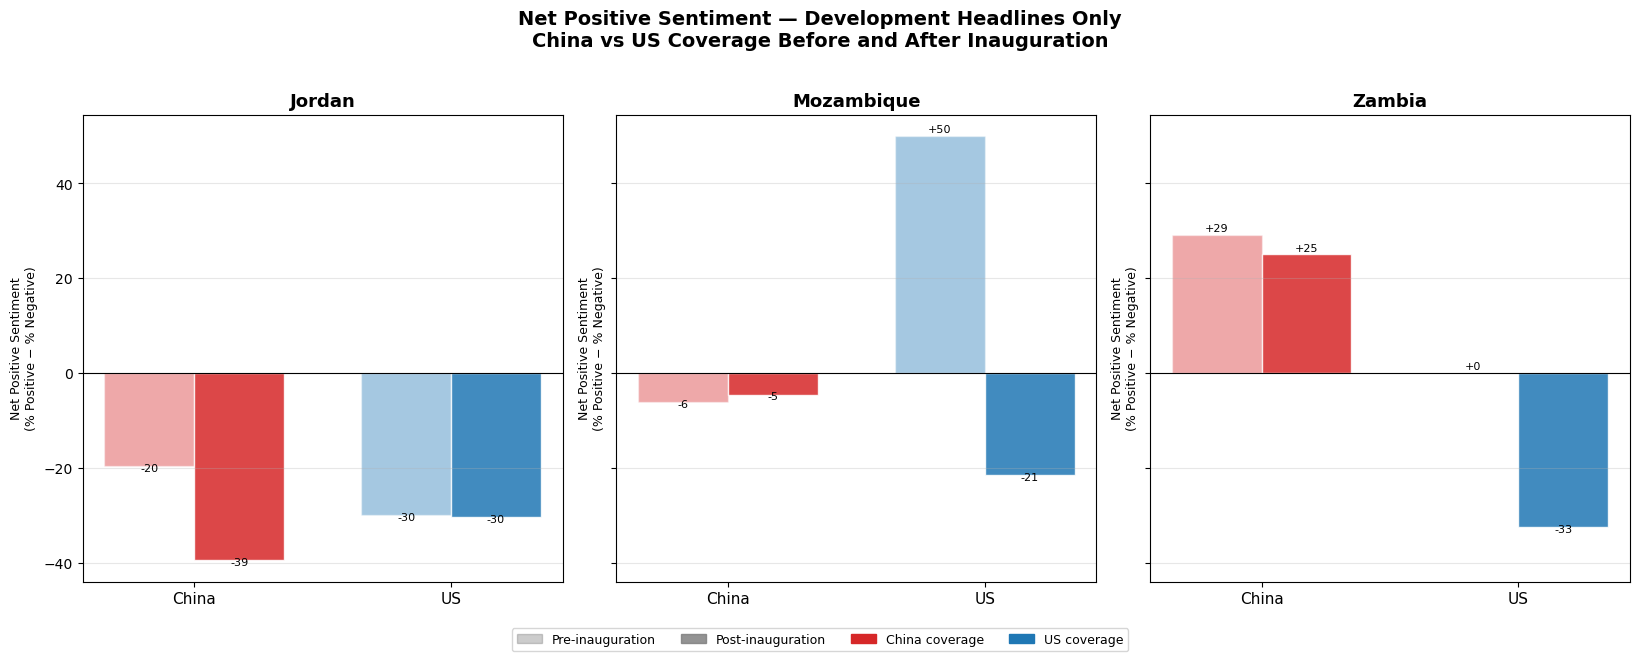

Saved -> ../output/sentiment_dev_combined.png


In [11]:
# Combined net sentiment — development headlines only
OUTPUT_DEV_NET = '../output/sentiment_dev_combined.png'

china_dev_net = net_sentiment_shift(df_china_dev, COUNTRIES)
china_dev_net['topic'] = 'China'
us_dev_net    = net_sentiment_shift(df_us_dev, COUNTRIES)
us_dev_net['topic'] = 'US'
net_dev_df = pd.concat([china_dev_net, us_dev_net])

fig, axes = plt.subplots(1, len(COUNTRIES), figsize=(5.5 * len(COUNTRIES), 6), sharey=True)
if len(COUNTRIES) == 1:
    axes = [axes]

topics   = ['China', 'US']
t_colors = {'China': '#d62728', 'US': '#1f77b4'}
periods  = ['Pre-inauguration', 'Post-inauguration']
x        = np.arange(len(topics))
width    = 0.35

for ax, country in zip(axes, COUNTRIES):
    for j, period in enumerate(periods):
        vals = []
        for topic in topics:
            sub = net_dev_df[(net_dev_df['country'] == country) &
                              (net_dev_df['period']  == period)  &
                              (net_dev_df['topic']   == topic)]
            vals.append(sub['net_positive'].values[0] if len(sub) > 0 else 0)
        offset = (j - 0.5) * width
        bars   = ax.bar(
            x + offset, vals, width,
            color=[t_colors[t] for t in topics],
            alpha=0.85 if period == 'Post-inauguration' else 0.40,
            edgecolor='white'
        )
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + (0.3 if val >= 0 else -1.5),
                    f'{val:+.0f}', ha='center', va='bottom', fontsize=8)

    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(country, fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(topics, fontsize=11)
    ax.set_ylabel('Net Positive Sentiment\n(% Positive − % Negative)', fontsize=9)
    ax.grid(axis='y', alpha=0.3)

legend_patches = [
    mpatches.Patch(color='gray', alpha=0.40, label='Pre-inauguration'),
    mpatches.Patch(color='gray', alpha=0.85, label='Post-inauguration'),
    mpatches.Patch(color=t_colors['China'], label='China coverage'),
    mpatches.Patch(color=t_colors['US'],    label='US coverage'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=4,
           fontsize=9, bbox_to_anchor=(0.5, -0.06))
fig.suptitle(
    'Net Positive Sentiment — Development Headlines Only\nChina vs US Coverage Before and After Inauguration',
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(OUTPUT_DEV_NET, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {OUTPUT_DEV_NET}')


In [ ]:
# Save framed development headlines
framed = pd.concat([
    df_china_dev.assign(entity='China'),
    df_us_dev.assign(entity='US')
])
framed.to_csv('../data/processed/framed_development_headlines.csv', index=False)
print(f'Saved {len(framed)} rows -> ../data/processed/framed_development_headlines.csv')
framed[['entity', 'country', 'period', 'frame', 'sentiment', 'title']].head(12)